In [17]:
import pandas as pd

In [18]:
df = pd.read_csv("./diabetes.csv")


In [19]:
df.rename(columns={'label':'is_diabetic'},inplace=True)

df.columns

Index(['pr', 'glucose', 'bp_diastolic', 'skin_triceps', 'insulin', 'bmi',
       'pedigree', 'age', 'is_diabetic'],
      dtype='str')

In [20]:
X=df["is_diabetic"]
y=df['glucose']

In [21]:
from sklearn.model_selection import train_test_split
# split data
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state=1)
# X_train is a 1D pandas Series, but sklearn.linear_model.LinearRegression.fit() expects 2D featu
X_train = X_train.to_numpy().reshape(-1, 1) # or: X_train.values.reshape(-1,1)
X_test = X_test.to_numpy().reshape(-1, 1) # or: X_test.values.reshape(-1,1)

In [22]:
from sklearn.linear_model import LinearRegression
rgsr = LinearRegression()

### Applying Gradient Descent

In [23]:
import numpy as np

In [24]:
# 1. Initialize parameters
b0 = 0.0 # Intercept
b1 = 0.0 # Slope
learning_rate = 0.0000001 # Small alpha because SAT scores are large
epochs = 1000 # Number of iterations
n = float(len(X_train)) # Number of elements in X_train

In [25]:
# Ensure X_train and y_train are flattened for calculation
x_vals = X_train.flatten()
y_vals = y_train.to_numpy()

In [26]:
# 2. The Gradient Descent Loop
for i in range(epochs):
    # Current prediction
    y_current = b1 * x_vals + b0
    # Calculate Gradients (Partial Derivatives)
    # D_b1 = -2/n * sum(x * (y_actual - y_predicted))
    # D_b0 = -2/n * sum(y_actual - y_predicted)
    D_b1 = (-2/n) * sum(x_vals * (y_vals - y_current))
    D_b0 = (-2/n) * sum(y_vals - y_current)
    # Update parameters
    b1 = b1 - learning_rate * D_b1
    b0 = b0 - learning_rate * D_b0
    
print(f"Final intercept (b0): {b0}")
print(f"Final slope (b1): {b1}")

Final intercept (b0): 0.024197628879207136
Final slope (b1): 0.009579110763511462


In [27]:
# 3. Make predictions on the test set
y_pred_gd = b1 * X_test.flatten() + b0

In [28]:
from sklearn import metrics

In [29]:
print('--- Gradient Descent Evaluation ---')
print("MAE:\t", metrics.mean_absolute_error(y_test, y_pred_gd))
print("MSE:\t", metrics.mean_squared_error(y_test, y_pred_gd))
print("RMSE:\t", np.sqrt(metrics.mean_squared_error(y_test, y_pred_gd)))
print("R-Squared:", metrics.r2_score(y_test, y_pred_gd))

--- Gradient Descent Evaluation ---
MAE:	 120.61788411373409
MSE:	 15677.34194442424
RMSE:	 125.20919273130164
R-Squared: -12.886474195916165


<Axes: title={'center': 'Manual Gradient Descent vs Actual'}>

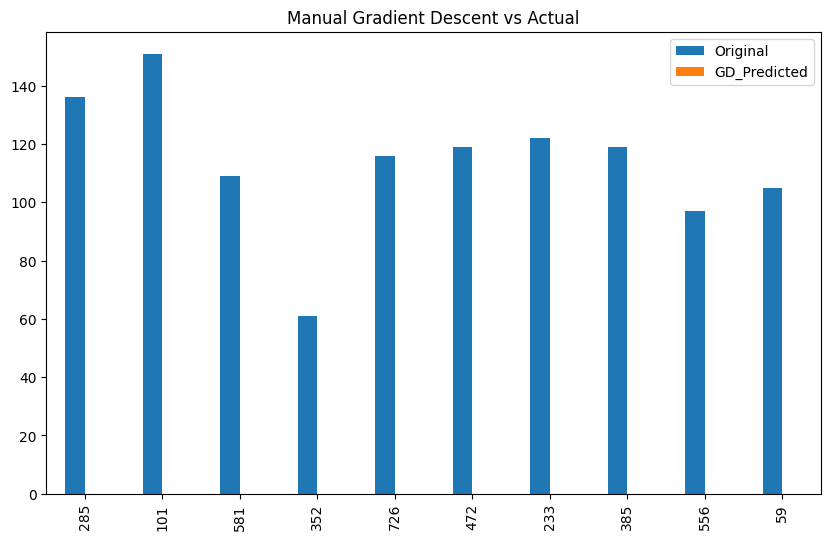

In [ ]:
# Visualization
y_comparison = pd.DataFrame({'Original': y_test, 'GD_Predicted': y_pred_gd})
y_comparison.head(10).plot(kind="bar", figsize=(10, 6), title="Manual Gradient Descent vs Actual")